# LIBRARY

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from collections import Counter
import scipy
import pandas as pd
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


In [90]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, classification_report,
                             roc_curve, auc)
import numpy as np
import matplotlib.pyplot as plt

In [91]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

In [92]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [93]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.calibration import CalibratedClassifierCV  # ← needed for predict_proba
import numpy as np

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report

In [95]:
def print_dist(y, label, binary=False):
    unique, counts = np.unique(y, return_counts=True)
    proportions    = counts / counts.sum()
    prefix         = 'binary=' if binary else 'sii='
    df = pd.DataFrame({
        'Class':      [f'{prefix}{u}' for u in unique],
        'Count':      counts,
        'Proportion': proportions.round(4),
        'Percentage': (proportions * 100).round(2)
    })
    print(f"\n{'='*60}")
    print(f"  SET: {label}")
    print(df.to_string(index=False))

# READ DATAFRAME

In [96]:
file_path = "../1.DATASET/CMI_FINAL_OD_SS.csv"
df=pd.read_csv(file_path)

In [97]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,-1.467073,-0.822843,-0.561893,-1.343231,-1.008221,-0.250870,-0.956432,-0.428812,-0.942872,-0.939966,-0.992591,-0.818300,-0.947148,-0.726336,-1.265162,-0.874740,-0.859871,2.0
1,1,-0.338700,-0.822843,-1.221382,-1.083906,-1.128018,0.630346,-0.657546,-0.367405,1.285851,-0.939966,-1.033298,-0.804797,-0.932563,-1.053662,-1.265162,-1.226847,-1.273565,0.0
2,2,-0.056607,1.215298,-0.614950,0.018225,-0.389269,-0.232187,1.018179,-1.466511,0.790579,0.280796,-0.662859,-0.199213,-0.347769,-0.314411,0.512640,-0.355318,-0.148634,0.0
3,3,-0.338700,-0.822843,-0.233502,-0.046607,-0.239523,-0.577200,0.665395,-0.367405,-0.695236,0.280796,-0.456268,0.057750,-0.249394,-0.126332,0.512640,-0.283279,0.116846,1.0
4,4,2.200139,1.215298,-0.315811,-0.224763,-0.375806,0.577087,-0.304761,1.210082,-0.198377,0.280796,3.297345,1.538145,-0.330005,-0.314411,0.512640,0.009328,-0.148634,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,-0.902887,1.215298,-0.735189,-1.334155,-1.060626,-0.281071,-0.789840,-0.392148,-0.695236,-2.160727,-1.012064,-0.820639,-0.817405,-1.103413,-1.265162,-1.004029,-0.941197,0.0
8378,8456,-0.056607,1.215298,-0.463799,-0.029751,-0.341052,-0.490946,-0.613448,-1.251639,-1.685780,0.280796,0.067523,-0.439950,-0.015430,-0.823890,-1.265162,-0.581341,-0.582047,1.0
8379,8457,-0.056607,1.215298,5.021847,-0.881633,1.293649,-0.249437,0.533101,-0.627980,0.542943,1.501557,-0.388344,-0.705917,1.239140,0.886735,0.512640,0.152734,-0.682526,0.0
8380,8458,1.353859,1.215298,0.742981,0.963464,0.974332,0.395292,-0.481153,1.201246,1.038215,-0.939966,0.058376,-0.447250,1.092211,0.366529,0.512640,1.420549,0.963516,2.0


In [98]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8382, 17)
y shape : (8382,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85}


# Data Preparation

In [99]:
X.shape

(8382, 17)

In [100]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85]))

In [101]:
Counter(y)

Counter({2.0: 936, 0.0: 5794, 1.0: 1567, 3.0: 85})

In [102]:
ctr = Counter(y)
ctr

Counter({2.0: 936, 0.0: 5794, 1.0: 1567, 3.0: 85})

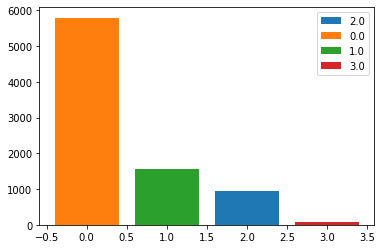

In [103]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange','tab:green','tab:red'])
plt.legend()
plt.show()

## Data Partitioning

In [104]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [106]:
X_train.shape

(5867, 17)

In [107]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59])),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26])))

In [108]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

In [109]:

print(f"Train samples : {len(y_train)}")
print(f"Test samples  : {len(y_test)}")

Train samples : 5867
Test samples  : 2515


# CASCADE LINEAR SVM

## model

In [110]:
param_list = [
    # l2 + hinge — requires dual=True
    {
        'C':            [0.001,0.01, 0.1, 1, 10],
        'penalty':      ['l1', 'l2'],
        'class_weight': ['balanced']
    }
]

In [111]:
def train_one_step_svm(X_train, y_binary, X_test, y_test_binary, step_name,
                       n_iter=50, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    # ── Random search on LinearSVC ────────────────────────────────────────────
    # NOTE: search on LinearSVC directly (faster)
    # calibration is applied AFTER finding best params
    random_search = RandomizedSearchCV(
        LinearSVC(random_state=random_state),
        param_distributions=param_list,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_macro',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
        error_score='raise',
    )
    random_search.fit(X_train, y_binary)

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    # ── Wrap best model with calibration to enable predict_proba ─────────────
    # LinearSVC has no predict_proba natively
    # CalibratedClassifierCV adds it via Platt scaling
    calibrated_model = CalibratedClassifierCV(
        LinearSVC(**random_search.best_params_,
                  random_state=random_state),
        cv=5
    )
    calibrated_model.fit(X_train, y_binary)

    # ── Predictions ───────────────────────────────────────────────────────────
    y_pred_binary = calibrated_model.predict(X_test)
    y_proba       = calibrated_model.predict_proba(X_test)[:, 1]  # P(positive)

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'not {step_name}', step_name]
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {step_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # ── Reports ───────────────────────────────────────────────────────────────
    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    print(f"    AUC                    : {roc_auc:.4f}")

    return calibrated_model     # ← return calibrated model, not raw LinearSVC

## split 

In [112]:
# 
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5867
Test samples   : 2515


In [113]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


  SET: TRAIN
  Class  Count  Proportion  Percentage
sii=0.0   4056      0.6913       69.13
sii=1.0   1097      0.1870       18.70
sii=2.0    655      0.1116       11.16
sii=3.0     59      0.0101        1.01

  SET: TEST
  Class  Count  Proportion  Percentage
sii=0.0   1738      0.6911       69.11
sii=1.0    470      0.1869       18.69
sii=2.0    281      0.1117       11.17
sii=3.0     26      0.0103        1.03


### class 0

In [114]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [115]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   1811      0.3087       30.87
binary=1   4056      0.6913       69.13

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11


In [116]:
from imblearn.over_sampling import SMOTE
over_dic={0:3500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 4056, 0: 3500})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [117]:
print_dist(y_res, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   3500      0.4632       46.32
binary=1   4056      0.5368       53.68

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11


In [118]:
models[0] = train_one_step_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=0')


  STEP: sii=0
  Training samples : 7556
  Positive class   : 4056 samples
  Negative class   : 3500 samples


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=50. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_te)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_te.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1644 samples


### class 1 

In [ ]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [ ]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1811
  Remaining test  : 1254

  SET: TRAIN after step 1
  Class  Count  Proportion  Percentage
sii=1.0   1097      0.6057       60.57
sii=2.0    655      0.3617       36.17
sii=3.0     59      0.0326        3.26

  SET: TEST  after step 1
  Class  Count  Proportion  Percentage
sii=0.0    477      0.3804       38.04
sii=1.0    470      0.3748       37.48
sii=2.0    281      0.2241       22.41
sii=3.0     26      0.0207        2.07


In [ ]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [ ]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    714      0.3943       39.43
binary=1   1097      0.6057       60.57

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    784      0.6252       62.52
binary=1    470      0.3748       37.48


In [ ]:
from imblearn.over_sampling import SMOTE
over_dic={0:900}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 1097, 0: 900})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [ ]:
print_dist(y_res, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    900      0.4507       45.07
binary=1   1097      0.5493       54.93

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    784      0.6252       62.52
binary=1    470      0.3748       37.48



  STEP: sii=1
  Training samples : 1997
  Positive class   : 1097 samples
  Negative class   : 900 samples


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=50. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number 


  Best params : {'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.01}
  Best CV F1  : 0.5806
  Test F1     : 0.5151


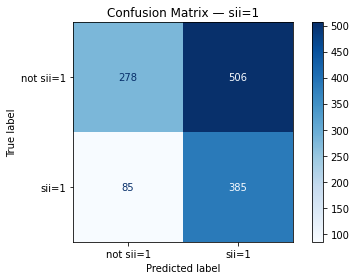

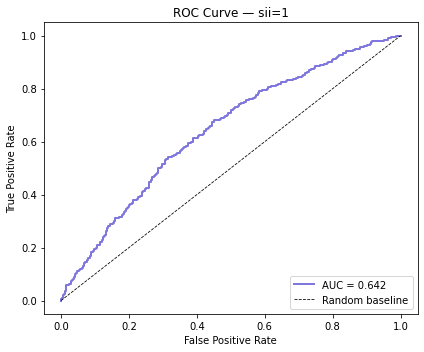

              precision    recall  f1-score   support

   not sii=1       0.77      0.35      0.48       784
       sii=1       0.43      0.82      0.57       470

    accuracy                           0.53      1254
   macro avg       0.60      0.59      0.53      1254
weighted avg       0.64      0.53      0.52      1254


  Confusion Matrix breakdown:
    TN (correct negatives) : 278
    FP (false positives)   : 506
    FN (false negatives)   : 85
    TP (correct positives) : 385
    AUC                    : 0.6424


In [ ]:
models[1] = train_one_step_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=1')

In [ ]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 891 samples


### class 2

In [ ]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [ ]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 714
  Remaining test  : 869

  SET: TRAIN after step 2
  Class  Count  Proportion  Percentage
sii=2.0    655      0.9174       91.74
sii=3.0     59      0.0826        8.26

  SET: TEST  after step 2
  Class  Count  Proportion  Percentage
sii=0.0    477      0.5489       54.89
sii=1.0     85      0.0978        9.78
sii=2.0    281      0.3234       32.34
sii=3.0     26      0.0299        2.99


In [ ]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [ ]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0826        8.26
binary=1    655      0.9174       91.74

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    588      0.6766       67.66
binary=1    281      0.3234       32.34


In [ ]:
from imblearn.over_sampling import SMOTE
over_dic={0:500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))


Resampled dataset shape Counter({1: 655, 0: 500})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [ ]:
print_dist(y_res, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0    500      0.4329       43.29
binary=1    655      0.5671       56.71

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    588      0.6766       67.66
binary=1    281      0.3234       32.34



  STEP: sii=2
  Training samples : 1155
  Positive class   : 655 samples
  Negative class   : 500 samples


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=50. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number 


  Best params : {'penalty': 'l1', 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.6509
  Test F1     : 0.3800


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


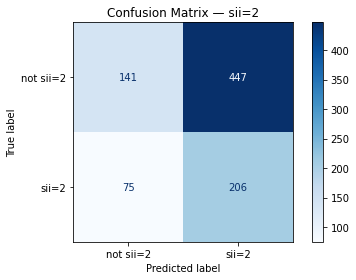

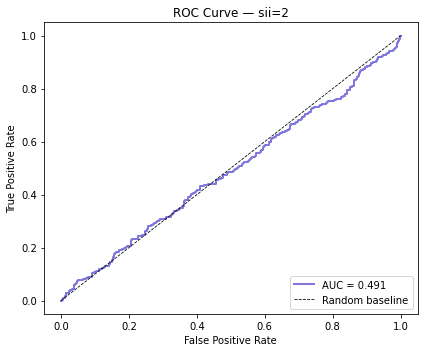

              precision    recall  f1-score   support

   not sii=2       0.65      0.24      0.35       588
       sii=2       0.32      0.73      0.44       281

    accuracy                           0.40       869
   macro avg       0.48      0.49      0.40       869
weighted avg       0.54      0.40      0.38       869


  Confusion Matrix breakdown:
    TN (correct negatives) : 141
    FP (false positives)   : 447
    FN (false negatives)   : 75
    TP (correct positives) : 206
    AUC                    : 0.4906


In [ ]:
models[2] = train_one_step_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=2')

In [ ]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 653 samples


### class 3 

In [ ]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 59
  Remaining test  : 663


In [ ]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 663 samples (all remaining)


## RESULTS

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2515        1738 1261 383 477     0.7670  0.7255 0.7457
   sii=1 vs [2,3]       1254         470  385 506  85     0.4321  0.8191 0.5658
     sii=2 vs [3]        869         281  206 447  75     0.3155  0.7331 0.4411
sii=3 (remaining)        663          26   26 637   0     0.0392  1.0000 0.0755


In [ ]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.73      0.84      1738
       sii=1       1.00      0.82      0.90       470
       sii=2       1.00      0.73      0.85       281
       sii=3       0.04      1.00      0.08        26

    accuracy                           0.75      2515
   macro avg       0.76      0.82      0.67      2515
weighted avg       0.99      0.75      0.84      2515



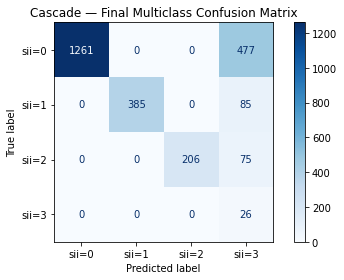

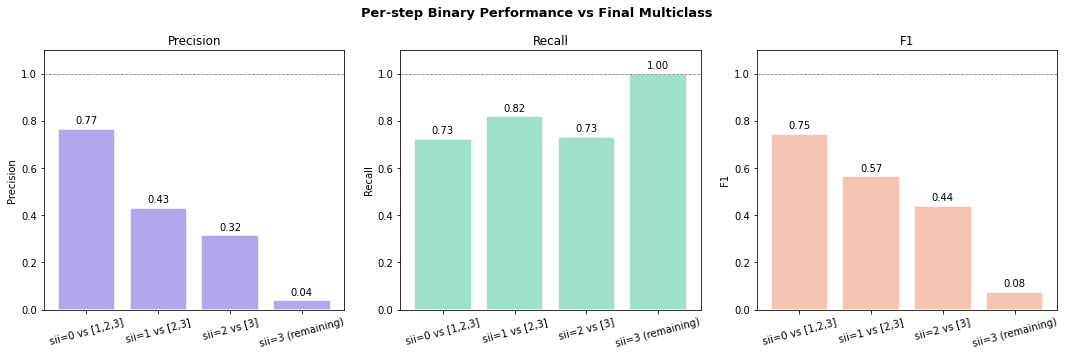

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1738   predicted: 1261
  sii=1 → true: 470    predicted: 385
  sii=2 → true: 281    predicted: 206
  sii=3 → true: 26     predicted: 663


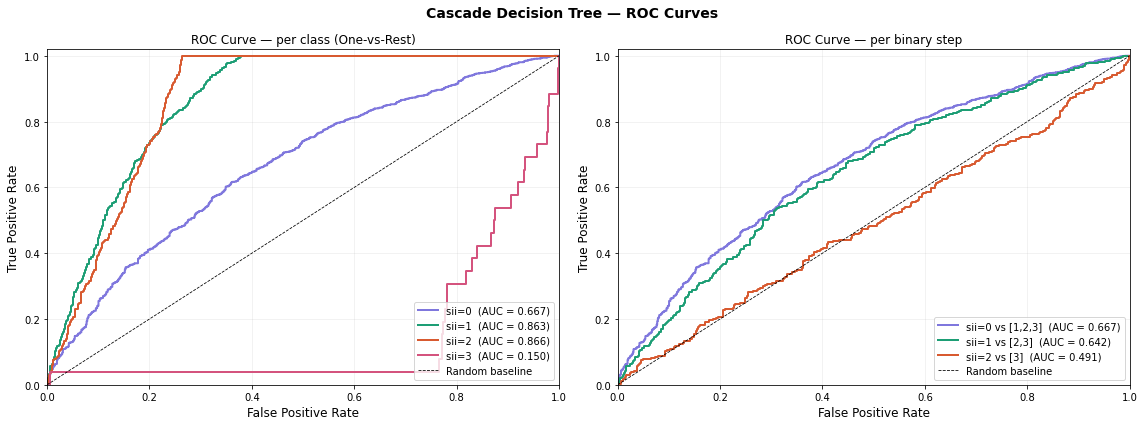


  AUC SUMMARY
  sii=0    → AUC = 0.6666
  sii=1    → AUC = 0.8629
  sii=2    → AUC = 0.8659
  sii=3    → AUC = 0.1505

  Macro AUC    : 0.6365
  Weighted AUC : 0.7202


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)

# CASCADE NON LINEAR SVM

## model

In [ ]:
param_list = [
    # RBF kernel — most commonly used non-linear kernel
    {
        'C':            [0.001, 0.01, 0.1, 1],#, 100],
        'kernel':       ['rbf'],
        'gamma':        ['auto'],
        'class_weight': ['balanced']
    },
    # # Polynomial kernel — good for image/text data
    {
         'C':            [0.001, 0.01, 0.1, 1],#, 100],, 100],
         'kernel':       ['poly'],
         'gamma':        ['auto'],
         'degree':       [2, 3, 4, 5],       # polynomial degree
         'coef0':        [0, 0.1, 0.5],   # independent term
         'class_weight': ['balanced'],
    },
    # # Sigmoid kernel — similar to neural network activation
    {
         'C':            [0.001, 0.01, 0.1, 1, 10],#, 100],, 100],
         'kernel':       ['sigmoid'],
         'gamma':        ['auto'],
         'coef0':        [0, 0.1, 0.5],
         'class_weight': ['balanced']
    }
]

In [ ]:
def train_one_step_non_svm(X_train, y_binary, X_test, y_test_binary, step_name,
                       n_iter=50, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    random_search = RandomizedSearchCV(
            SVC(probability=True, random_state=random_state),
            param_distributions=param_list,
            cv=KFold(n_splits=n_splits, shuffle=True,random_state=random_state),
            scoring='f1_weighted',
            n_jobs=-1,
            refit=True,
            n_iter=n_iter,
            random_state=random_state
    )
    random_search.fit(X_train, y_binary)

    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_binary)

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    # ── Predictions ───────────────────────────────────────────────────────────
    y_pred_binary = best_model.predict(X_test)
    y_proba       = best_model.predict_proba(X_test)[:, 1]  # ← P(positive class)
                                                             #   only 2 columns in binary

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'not {step_name}', step_name]
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {step_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # ── Reports ───────────────────────────────────────────────────────────────
    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    print(f"    AUC                    : {roc_auc:.4f}")

    return best_model

## split 

In [ ]:
# 
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5867
Test samples   : 2515


In [ ]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


  SET: TRAIN
  Class  Count  Proportion  Percentage
sii=0.0   4056      0.6913       69.13
sii=1.0   1097      0.1870       18.70
sii=2.0    655      0.1116       11.16
sii=3.0     59      0.0101        1.01

  SET: TEST
  Class  Count  Proportion  Percentage
sii=0.0   1738      0.6911       69.11
sii=1.0    470      0.1869       18.69
sii=2.0    281      0.1117       11.17
sii=3.0     26      0.0103        1.03


### class 0

In [ ]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [ ]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   1811      0.3087       30.87
binary=1   4056      0.6913       69.13

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11


In [ ]:
from imblearn.over_sampling import SMOTE
over_dic={0:3500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 4056, 0: 3500})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [ ]:
print_dist(y_res, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   3500      0.4632       46.32
binary=1   4056      0.5368       53.68

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11



  STEP: sii=0
  Training samples : 7556
  Positive class   : 4056 samples
  Negative class   : 3500 samples

  Best params : {'kernel': 'poly', 'gamma': 'auto', 'degree': 5, 'coef0': 0.5, 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.6712
  Test F1     : 0.6173


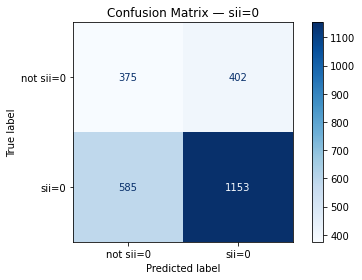

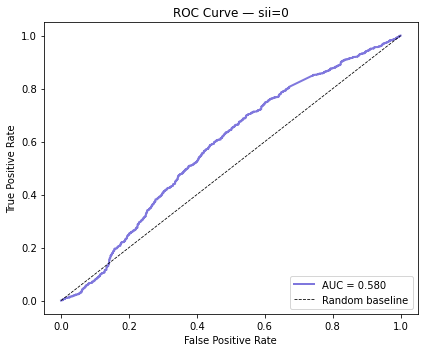

              precision    recall  f1-score   support

   not sii=0       0.39      0.48      0.43       777
       sii=0       0.74      0.66      0.70      1738

    accuracy                           0.61      2515
   macro avg       0.57      0.57      0.57      2515
weighted avg       0.63      0.61      0.62      2515


  Confusion Matrix breakdown:
    TN (correct negatives) : 375
    FP (false positives)   : 402
    FN (false negatives)   : 585
    TP (correct positives) : 1153
    AUC                    : 0.5795


In [ ]:
models[0] = train_one_step_non_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=0')

In [ ]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_te)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_te.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1555 samples


### class 1 

In [ ]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [ ]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1811
  Remaining test  : 1362

  SET: TRAIN after step 1
  Class  Count  Proportion  Percentage
sii=1.0   1097      0.6057       60.57
sii=2.0    655      0.3617       36.17
sii=3.0     59      0.0326        3.26

  SET: TEST  after step 1
  Class  Count  Proportion  Percentage
sii=0.0    585      0.4295       42.95
sii=1.0    470      0.3451       34.51
sii=2.0    281      0.2063       20.63
sii=3.0     26      0.0191        1.91


In [ ]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [ ]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    714      0.3943       39.43
binary=1   1097      0.6057       60.57

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    892      0.6549       65.49
binary=1    470      0.3451       34.51


In [ ]:
from imblearn.over_sampling import SMOTE
over_dic={0:900}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 1097, 0: 900})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [ ]:
print_dist(y_res, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    900      0.4507       45.07
binary=1   1097      0.5493       54.93

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    892      0.6549       65.49
binary=1    470      0.3451       34.51



  STEP: sii=1
  Training samples : 1997
  Positive class   : 1097 samples
  Negative class   : 900 samples

  Best params : {'kernel': 'poly', 'gamma': 'auto', 'degree': 5, 'coef0': 0.5, 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.6100
  Test F1     : 0.4996


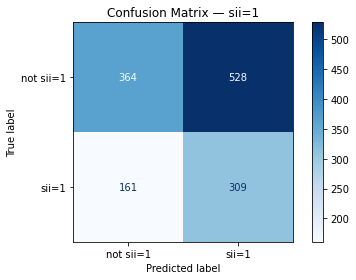

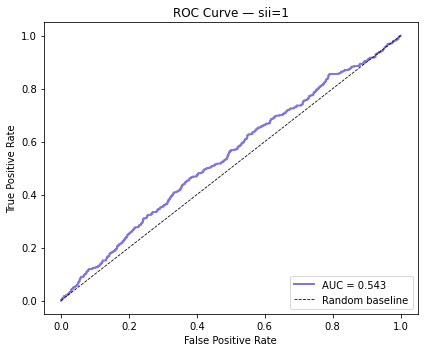

              precision    recall  f1-score   support

   not sii=1       0.69      0.41      0.51       892
       sii=1       0.37      0.66      0.47       470

    accuracy                           0.49      1362
   macro avg       0.53      0.53      0.49      1362
weighted avg       0.58      0.49      0.50      1362


  Confusion Matrix breakdown:
    TN (correct negatives) : 364
    FP (false positives)   : 528
    FN (false negatives)   : 161
    TP (correct positives) : 309
    AUC                    : 0.5426


In [ ]:
models[1] = train_one_step_non_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=1')

In [ ]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 837 samples


### class 2

In [ ]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [ ]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 714
  Remaining test  : 1053

  SET: TRAIN after step 2
  Class  Count  Proportion  Percentage
sii=2.0    655      0.9174       91.74
sii=3.0     59      0.0826        8.26

  SET: TEST  after step 2
  Class  Count  Proportion  Percentage
sii=0.0    585      0.5556       55.56
sii=1.0    161      0.1529       15.29
sii=2.0    281      0.2669       26.69
sii=3.0     26      0.0247        2.47


In [ ]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [ ]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0826        8.26
binary=1    655      0.9174       91.74

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    772      0.7331       73.31
binary=1    281      0.2669       26.69


In [ ]:
from imblearn.over_sampling import SMOTE
over_dic={0:500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))


Resampled dataset shape Counter({1: 655, 0: 500})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [ ]:
print_dist(y_res, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0    500      0.4329       43.29
binary=1    655      0.5671       56.71

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    772      0.7331       73.31
binary=1    281      0.2669       26.69



  STEP: sii=2
  Training samples : 1155
  Positive class   : 655 samples
  Negative class   : 500 samples



  Best params : {'kernel': 'poly', 'gamma': 'auto', 'degree': 5, 'coef0': 0.5, 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.8877
  Test F1     : 0.3679


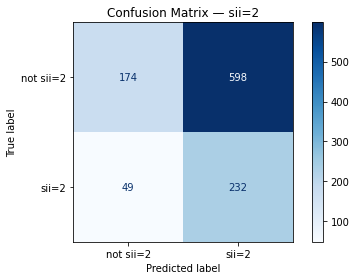

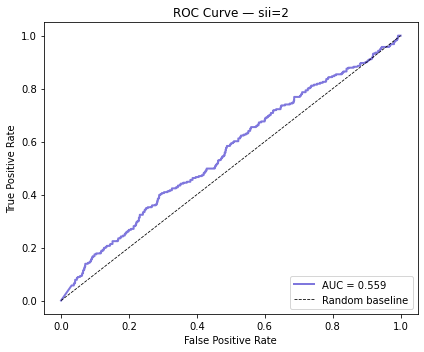

              precision    recall  f1-score   support

   not sii=2       0.78      0.23      0.35       772
       sii=2       0.28      0.83      0.42       281

    accuracy                           0.39      1053
   macro avg       0.53      0.53      0.38      1053
weighted avg       0.65      0.39      0.37      1053


  Confusion Matrix breakdown:
    TN (correct negatives) : 174
    FP (false positives)   : 598
    FN (false negatives)   : 49
    TP (correct positives) : 232
    AUC                    : 0.5590


In [ ]:
models[2] = train_one_step_non_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=2')

In [ ]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 830 samples


### class 3 

In [ ]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 59
  Remaining test  : 821


In [ ]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 821 samples (all remaining)


## RESULTS

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2515        1738 1153 402 585     0.7415  0.6634 0.7003
   sii=1 vs [2,3]       1362         470  309 528 161     0.3692  0.6574 0.4728
     sii=2 vs [3]       1053         281  232 598  49     0.2795  0.8256 0.4176
sii=3 (remaining)        821          26   26 795   0     0.0317  1.0000 0.0614


In [ ]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.66      0.80      1738
       sii=1       1.00      0.66      0.79       470
       sii=2       1.00      0.83      0.90       281
       sii=3       0.03      1.00      0.06        26

    accuracy                           0.68      2515
   macro avg       0.76      0.79      0.64      2515
weighted avg       0.99      0.68      0.80      2515



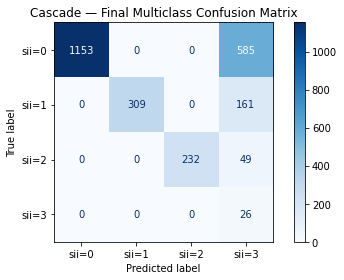

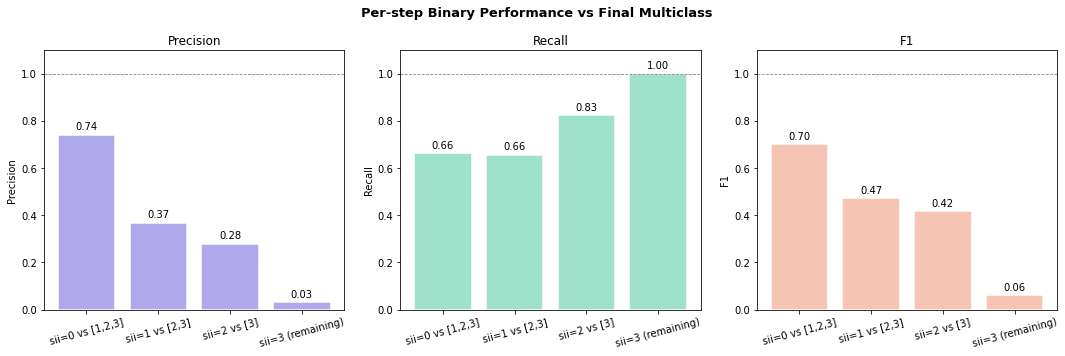

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1738   predicted: 1153
  sii=1 → true: 470    predicted: 309
  sii=2 → true: 281    predicted: 232
  sii=3 → true: 26     predicted: 821


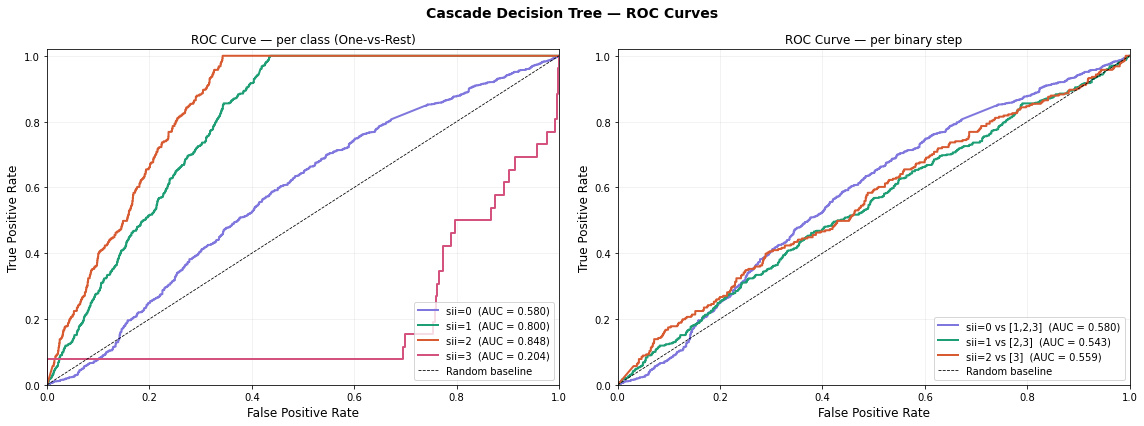


  AUC SUMMARY
  sii=0    → AUC = 0.5795
  sii=1    → AUC = 0.8005
  sii=2    → AUC = 0.8476
  sii=3    → AUC = 0.2044

  Macro AUC    : 0.6080
  Weighted AUC : 0.6469


In [ ]:
# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)

# NON LINEAR SVM

  RANDOM SEARCH — SVM non lineare
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/


── Best hyperparameters found ──────────────────────────
  kernel         : sigmoid
  gamma          : auto
  coef0          : 0
  class_weight   : balanced
  C              : 1

  F1-weighted (CV): 0.3618

── Classification Report (Test set) ───────────────────────
              precision    recall  f1-score   support

         0.0       0.84      0.11      0.20      1738
         1.0       0.18      0.43      0.25       470
         2.0       0.14      0.48      0.21       281
         3.0       0.01      0.04      0.01        26

    accuracy                           0.21      2515
   macro avg       0.29      0.26      0.17      2515
weighted avg       0.63      0.21      0.21      2515

  F1-weighted (Test):  0.2052
  F1-weighted (CV):    0.3618
  Delta CV→Test:       -0.1565  (attenzione: possibile overfitting)


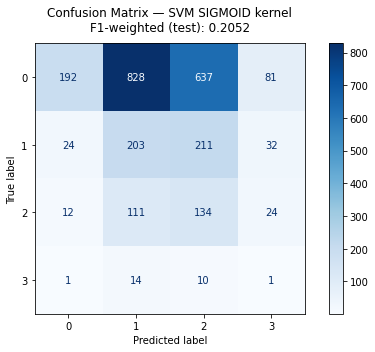


  Confusion matrix salvata in confusion_matrix_svm.png


In [ ]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 30

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_list = [
    # RBF kernel
    {
        "C":            [0.001, 0.01, 0.1, 1],
        "kernel":       ["rbf"],
        "gamma":        ["auto"],
        "class_weight": ["balanced"],
    },
    # Polynomial kernel
    {
        "C":            [0.001, 0.01, 0.1, 1],
        "kernel":       ["poly"],
        "gamma":        ["auto"],
        "degree":       [2, 3, 4, 5],
        "coef0":        [0, 0.1, 0.5],
        "class_weight": ["balanced"],
    },
    # Sigmoid kernel
    {
        "C":            [0.001, 0.01, 0.1, 1],
        "kernel":       ["sigmoid"],
        "gamma":        ["auto"],
        "coef0":        [0, 0.1],
        "class_weight": ["balanced"],
    },
]

"""over_dic={1:1500, 2:1500, 3:500}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
X_res, y_res = over.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))"""

# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — SVM non lineare")
print("=" * 60)

random_search = RandomizedSearchCV(
    SVC(probability=True, random_state=random_state, max_iter=2000),
    param_distributions=param_list,
    cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True,          # riaddestra automaticamente sul dataset completo
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<15}: {value}")

print(f"\n  F1-weighted (CV): {random_search.best_score_:.4f}")

# ── Modello migliore (già refit sul training set completo) ───────────────────
best_model = random_search.best_estimator_

# ── Previsioni sul test set ──────────────────────────────────────────────────
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)   # probabilità per classe

# ── Metriche ─────────────────────────────────────────────────────────────────
print("\n── Classification Report (Test set) ───────────────────────")
print(classification_report(y_test, y_pred))

f1_test = f1_score(y_test, y_pred, average="weighted")
print(f"  F1-weighted (Test):  {f1_test:.4f}")
print(f"  F1-weighted (CV):    {random_search.best_score_:.4f}")
delta = f1_test - random_search.best_score_
print(f"  Delta CV→Test:       {delta:+.4f}  {'(ok)' if abs(delta) < 0.05 else '(attenzione: possibile overfitting)'}")

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(
    f"Confusion Matrix — SVM {random_search.best_params_['kernel'].upper()} kernel\n"
    f"F1-weighted (test): {f1_test:.4f}",
    fontsize=12,
    pad=12,
)
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150)
plt.show()
print("\n  Confusion matrix salvata in confusion_matrix_svm.png")